<a href="https://colab.research.google.com/github/Kishanmvs/Data-Mining-Project/blob/main/Module_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODULE 4: Classification Modeling & Evaluation
## BCI606 – Data Mining Mini Project | Domain: Global Space Exploration Analytics

> **Goal:** Train three supervised ML classifiers to predict whether a space mission will be  
> **HIGH_SUCCESS** (Success Rate ≥ 70%) or **AT_RISK** (< 70%) from pre-launch parameters.

**Classifiers covered:**  
1. Decision Tree (Gini Impurity)  
2. Gaussian Naïve Bayes  
3. k-Nearest Neighbours (k-NN)


## 0  Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, os

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve,
    auc, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
os.makedirs("datasets", exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
print("Libraries loaded ✓")


Libraries loaded ✓


## 1  Load the Raw Dataset

In [ ]:
# ---------------------------------------------------------------
# Change this path if your CSV lives elsewhere
# ---------------------------------------------------------------
DATA_PATH = "Global_Space_Exploration_Dataset.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset shape : {df_raw.shape}")
print(f"Columns       : {df_raw.columns.tolist()}")
df_raw.head()


Dataset shape : (3000, 12)
Columns       : ['Country', 'Year', 'Mission Name', 'Mission Type', 'Launch Site', 'Satellite Type', 'Budget (in Billion $)', 'Success Rate (%)', 'Technology Used', 'Environmental Impact', 'Collaborating Countries', 'Duration (in Days)']


,Country,Year,Mission Name,Mission Type,Launch Site,Satellite Type,Budget (in Billion $),Success Rate (%),Technology Used,Environmental Impact,Collaborating Countries,Duration (in Days)
0,China,2008,Sharable tertiary superstructure,Manned,Sheilatown,Communication,16.20,90,Nuclear Propulsion,Medium,"France, UK, Russia",112
1,Japan,2018,Re-engineered composite flexibility,Manned,New Ericfurt,Communication,29.04,99,Solar Propulsion,High,"Germany, Israel",236
2,Israel,2013,Reactive disintermediate projection,Manned,Port Kaitlynstad,Communication,28.73,54,AI Navigation,Medium,"China, Israel, USA",238
3,UAE,2010,Grass-roots 6thgeneration implementation,Unmanned,Mariastad,Spy,37.27,58,Traditional Rocket,Low,USA,186
4,India,2006,Balanced discrete orchestration,Manned,North Jasonborough,Weather,18.95,91,Solar Propulsion,Medium,"Israel, China, India",277


## 2  Exploratory Data Analysis (EDA)

In [ ]:
# --- Basic info ---
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  3000 non-null   object 
 1   Year                     3000 non-null   int64  
 2   Mission Name             3000 non-null   object 
 3   Mission Type             3000 non-null   object 
 4   Launch Site              3000 non-null   object 
 5   Satellite Type           3000 non-null   object 
 6   Budget (in Billion $)    3000 non-null   float64
 7   Success Rate (%)         3000 non-null   int64  
 8   Technology Used          3000 non-null   object 
 9   Environmental Impact     3000 non-null   object 
 10  Collaborating Countries  3000 non-null   object 
 11  Duration (in Days)       3000 non-null   int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 281.4+ KB


In [ ]:
# --- Descriptive statistics for numeric columns ---
df_raw.describe().round(2)


,Year,Budget (in Billion $),Success Rate (%),Duration (in Days)
count,3000.00,3000.00,3000.00,3000.00
mean,2012.47,25.43,74.98,181.48
std,7.44,14.11,14.95,104.98
min,2000.00,0.53,50.00,1.00
25%,2006.00,12.98,62.00,91.00
50%,2012.00,25.49,75.00,180.00
75%,2019.00,37.60,88.00,272.00
max,2025.00,49.97,100.00,365.00


In [ ]:
# --- Missing values ---
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None — dataset is complete ✓")


Missing values per column:
None — dataset is complete ✓


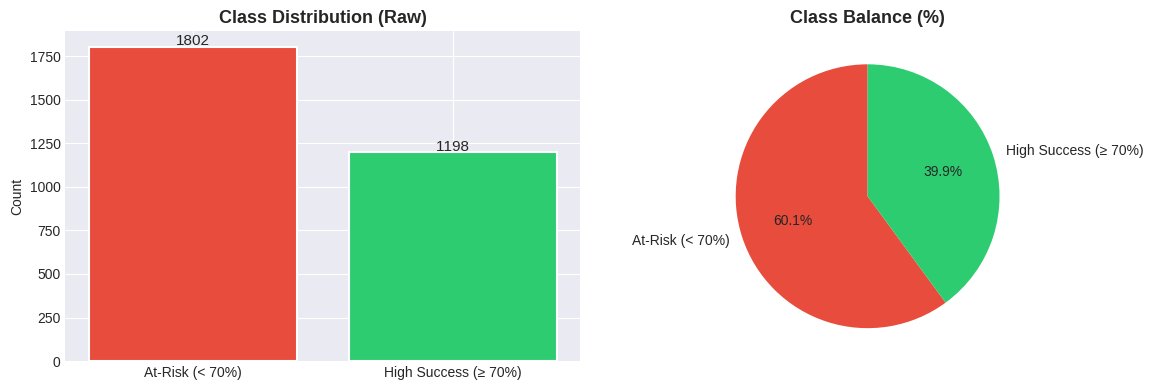


Class counts:
is_high_success
1    1802
0    1198


In [ ]:
# --- Target distribution (raw) ---
threshold = 70
df_raw['is_high_success'] = (df_raw['Success Rate (%)'] >= threshold).astype(int)
counts = df_raw['is_high_success'].value_counts()
labels = ['At-Risk (< 70%)', 'High Success (≥ 70%)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11)

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Class Balance (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('datasets/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nClass counts:\n{counts.to_string()}")


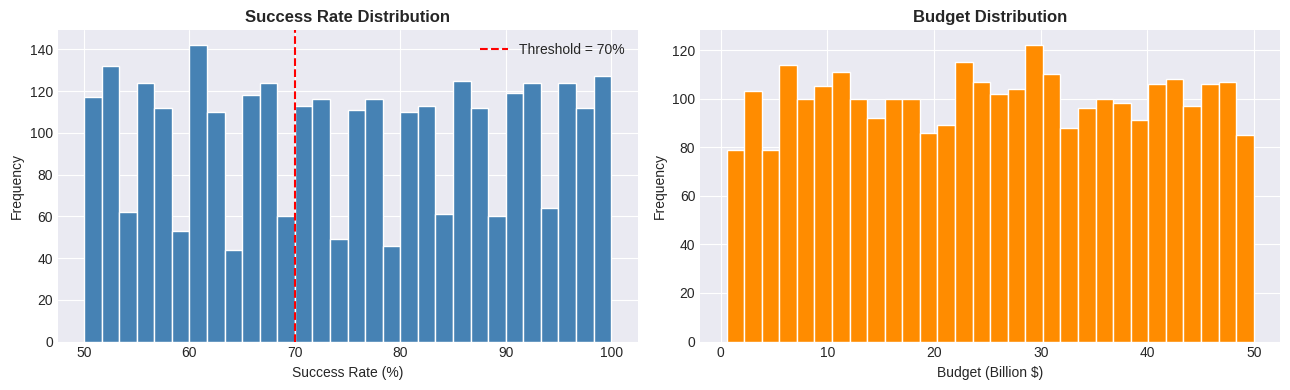

In [ ]:
# --- Success Rate distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_raw['Success Rate (%)'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}%')
axes[0].set_title('Success Rate Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Success Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df_raw['Budget (in Billion $)'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Budget Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Budget (Billion $)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('datasets/eda_numeric_distributions.png', dpi=150)
plt.show()


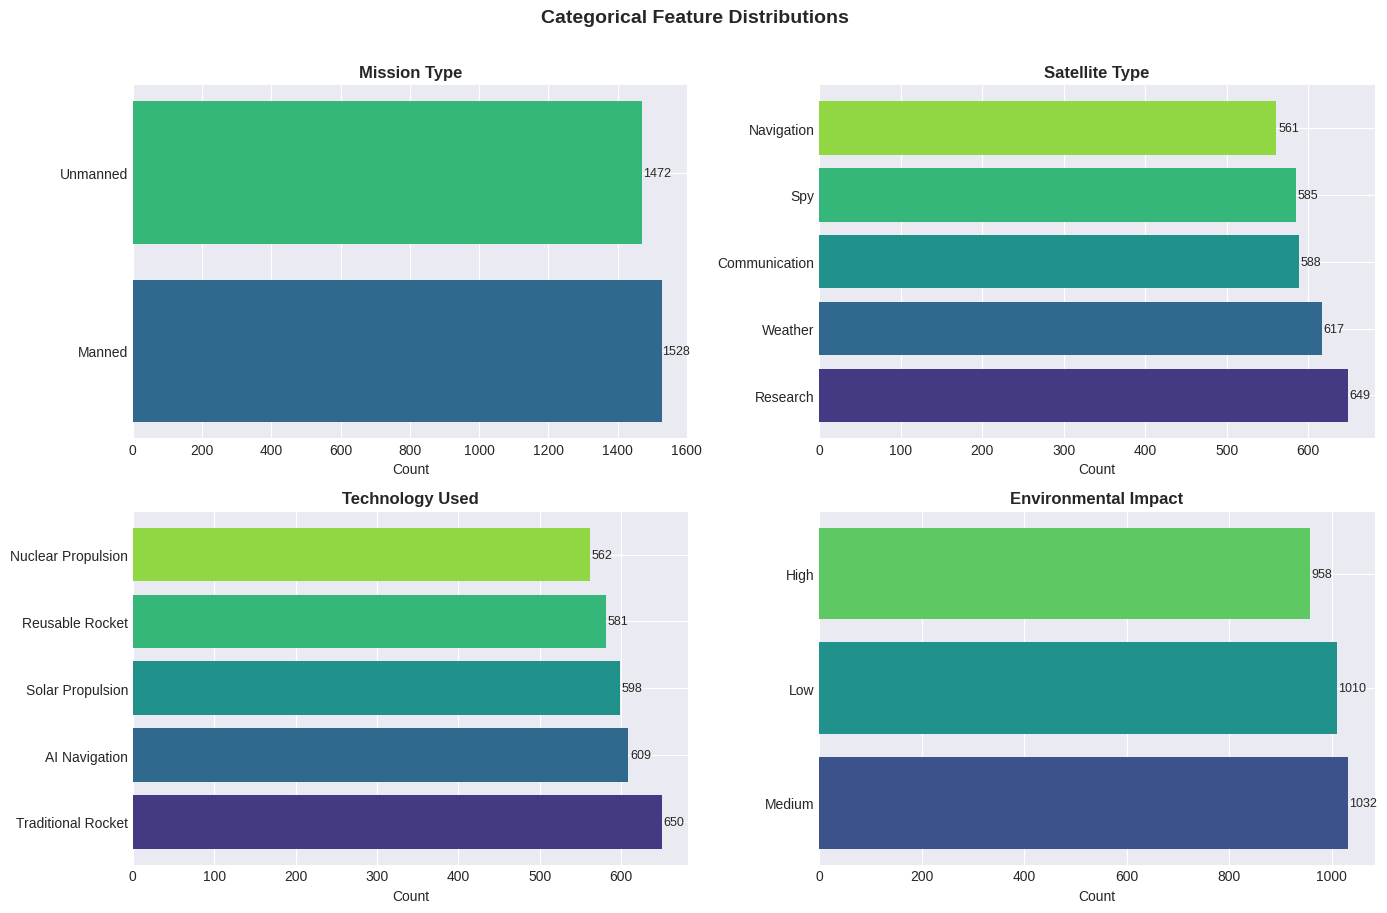

In [ ]:
# --- Categorical feature counts ---
cat_cols = ['Mission Type', 'Satellite Type', 'Technology Used', 'Environmental Impact']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    vc = df_raw[col].value_counts()
    ax.barh(vc.index, vc.values, color=sns.color_palette("viridis", len(vc)))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(vc.values):
        ax.text(v + 2, i, str(v), va='center', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('datasets/eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


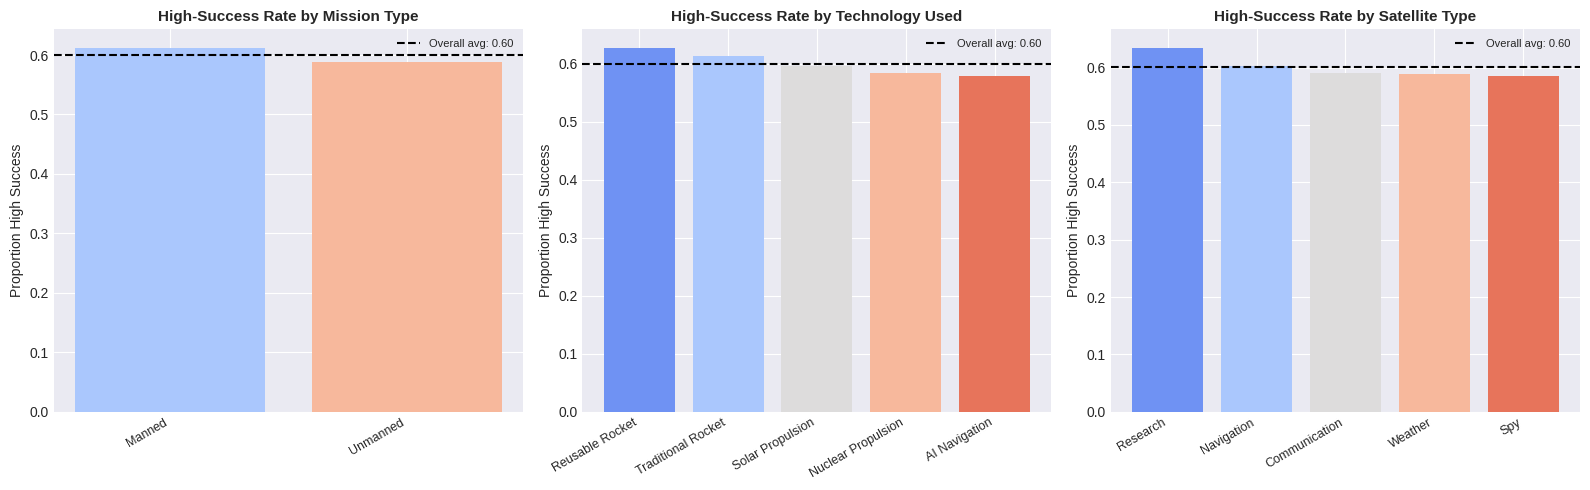

In [ ]:
# --- Success rate by key categories ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Mission Type', 'Technology Used', 'Satellite Type']):
    grp = df_raw.groupby(col)['is_high_success'].mean().sort_values(ascending=False)
    ax.bar(grp.index, grp.values, color=sns.color_palette("coolwarm", len(grp)))
    ax.set_title(f'High-Success Rate by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Proportion High Success')
    ax.set_xticklabels(grp.index, rotation=30, ha='right', fontsize=9)
    ax.axhline(df_raw['is_high_success'].mean(), color='black', linestyle='--',
               label=f'Overall avg: {df_raw["is_high_success"].mean():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('datasets/eda_success_by_category.png', dpi=150)
plt.show()


## 3  Preprocessing

## 3.1  Mathematical foundations (Gini / NB / k-NN)

**Decision Tree — Gini Impurity**
$$Gini(S) = 1 - \sum_i p_i^2$$

**Naïve Bayes — Gaussian likelihood**
$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\!\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

**k-NN — Euclidean distance**
$$d(x,x') = \sqrt{\sum_i (x_i - x'_i)^2}$$


In [ ]:
# --- Feature engineering & encoding ---
df = df_raw.copy()

# Target (already created above)
# Drop raw target column to avoid leakage
df.drop(columns=['Success Rate (%)'], inplace=True)

# Drop free-text / identifier columns
df.drop(columns=['Mission Name', 'Launch Site'], inplace=True, errors='ignore')

# Encode 'Collaborating Countries' as count of collaborators
df['Num_Collaborators'] = df['Collaborating Countries'].fillna('').apply(
    lambda x: len([c.strip() for c in x.split(',') if c.strip()])
)
df.drop(columns=['Collaborating Countries'], inplace=True)

# Label-encode remaining categoricals
le = LabelEncoder()
cat_features = ['Country', 'Mission Type', 'Satellite Type',
                'Technology Used', 'Environmental Impact']

for col in cat_features:
    df[col] = le.fit_transform(df[col].astype(str))

print("Feature columns after encoding:")
print([c for c in df.columns if c != 'is_high_success'])
df.head()


Feature columns after encoding:
['Country', 'Year', 'Mission Type', 'Satellite Type', 'Budget (in Billion $)', 'Technology Used', 'Environmental Impact', 'Duration (in Days)', 'Num_Collaborators']


,Country,Year,Mission Type,Satellite Type,Budget (in Billion $),Technology Used,Environmental Impact,Duration (in Days),is_high_success,Num_Collaborators
0,0,2008,0,0,16.20,1,2,112,1,3
1,5,2018,0,0,29.04,3,0,236,1,2
2,4,2013,0,0,28.73,0,2,238,0,3
3,7,2010,1,3,37.27,4,1,186,0,1
4,3,2006,0,4,18.95,3,2,277,1,3


In [ ]:
# --- Train / Test split ---
X = df.drop(columns=['is_high_success'])
y = df['is_high_success']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size : {X_train_raw.shape[0]} rows")
print(f"Test  size : {X_test_raw.shape[0]} rows")
print(f"Train class balance : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance : {y_test.value_counts(normalize=True).round(3).to_dict()}")


Train size : 2400 rows
Test  size : 600 rows
Train class balance : {1: 0.601, 0: 0.399}
Test  class balance : {1: 0.6, 0: 0.4}


In [ ]:
# --- Z-score standardisation (critical for k-NN) ---
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),  columns=X.columns)

print("Features standardised ✓  (mean ≈ 0, std ≈ 1 on training set)")


Features standardised ✓  (mean ≈ 0, std ≈ 1 on training set)


In [ ]:
# --- Optional SMOTE for class balancing (requires imbalanced-learn) ---
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
    print(f"After SMOTE: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}")
    USE_SMOTE = True
except ImportError:
    X_train_bal, y_train_bal = X_train, y_train
    print("imbalanced-learn not installed — using original split (install with: pip install imbalanced-learn)")
    USE_SMOTE = False


After SMOTE: {np.int64(0): np.int64(1442), np.int64(1): np.int64(1442)}


## 4  Model Definitions & Hyperparameter Justification

> **Decision Tree hyperparameters**  
> - `max_depth=8` — prevents memorisation (deep trees grow until every leaf is pure)  
> - `min_samples_split=15` — requires 15 missions before attempting a split  
> - `min_samples_leaf=8` — each leaf must represent ≥ 8 missions  
>  
> **Gaussian Naïve Bayes**  
> - `var_smoothing=1e-9` — prevents division-by-zero for near-zero variance features  
>  
> **k-NN**  
> - `n_neighbors=7` — odd to break ties; ≈ √(n_features) heuristic  
> - `metric='euclidean'` — valid because all features are Z-score scaled  
> - `weights='distance'` — closer missions have more influence


In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        criterion='gini', max_depth=8,
        min_samples_split=15, min_samples_leaf=8,
        random_state=42
    ),
    "Naive Bayes (Gaussian)": GaussianNB(var_smoothing=1e-9),
    "k-NN (k=7)": KNeighborsClassifier(
        n_neighbors=7, metric='euclidean',
        weights='distance', n_jobs=-1
    ),
}

for name, m in models.items():
    print(f"  {name}: {m}")


  Decision Tree: DecisionTreeClassifier(max_depth=8, min_samples_leaf=8, min_samples_split=15,
                       random_state=42)
  Naive Bayes (Gaussian): GaussianNB()
  k-NN (k=7): KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=7,
                     weights='distance')


## 5  Training & Evaluation

> **Metric glossary**  
> - *Accuracy* — misleading when imbalanced; a "always High-Success" model gets ~60 %  
> - *Precision* — of missions flagged as High-Success, how many truly are?  
> - *Recall* — of all actual High-Success missions, how many did we catch?  
> - *F1-Score* — harmonic mean of Precision & Recall; **primary comparison metric**  
> - *ROC-AUC* — threshold-independent discrimination ability (0.5 = random, 1 = perfect)  
> - *PR-AUC* — more informative than ROC-AUC when the positive class is the minority



  Training  :  Decision Tree
  Train time : 0.019s  |  Predict time : 0.00293s
  Accuracy   : 0.4617
  Precision  : 0.5678
  Recall     : 0.4306
  F1-Score   : 0.4897
  ROC-AUC    : 0.4788
  PR-AUC     : 0.6150
              precision    recall  f1-score   support

     At-Risk     0.3731    0.5083    0.4303       240
High Success     0.5678    0.4306    0.4897       360

    accuracy                         0.4617       600
   macro avg     0.4704    0.4694    0.4600       600
weighted avg     0.4899    0.4617    0.4660       600


  Training  :  Naive Bayes (Gaussian)
  Train time : 0.003s  |  Predict time : 0.00287s
  Accuracy   : 0.4917
  Precision  : 0.5868
  Recall     : 0.5167
  F1-Score   : 0.5495
  ROC-AUC    : 0.4731
  PR-AUC     : 0.5821
              precision    recall  f1-score   support

     At-Risk     0.3852    0.4542    0.4168       240
High Success     0.5868    0.5167    0.5495       360

    accuracy                         0.4917       600
   macro avg     0.486

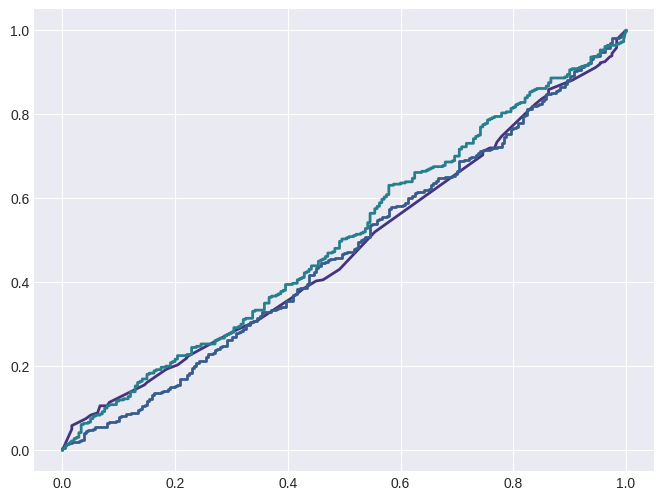

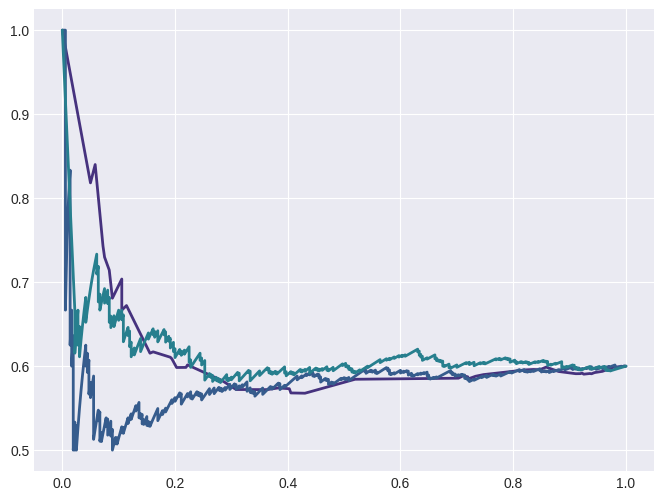

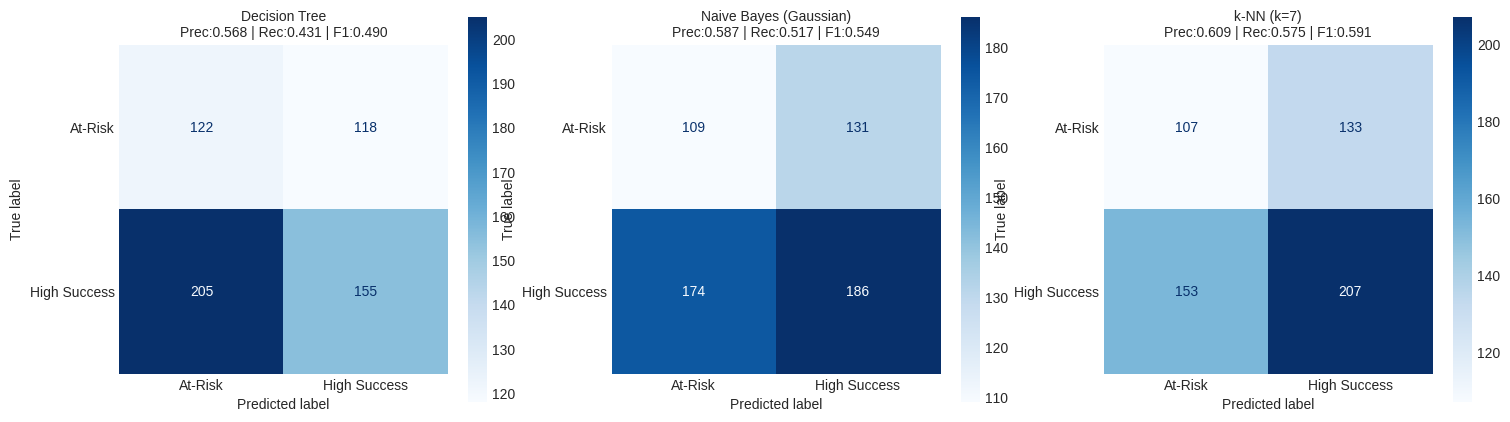

In [ ]:
results  = {}
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
fig_pr,  ax_pr  = plt.subplots(figsize=(8, 6))
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))

X_tr = X_train_bal if USE_SMOTE else X_train
y_tr = y_train_bal if USE_SMOTE else y_train

for idx, (name, model) in enumerate(models.items()):
    print(f"\n{'='*60}")
    print(f"  Training  :  {name}")

    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    pred_time = time.time() - t1

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred)
    rec   = recall_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred)
    roc_v = roc_auc_score(y_test, y_prob)

    prec_v, rec_v, _ = precision_recall_curve(y_test, y_prob)
    pr_v = auc(rec_v, prec_v)

    results[name] = {
        'Accuracy':        round(acc,   4),
        'Precision':       round(prec,  4),
        'Recall':          round(rec,   4),
        'F1-Score':        round(f1,    4),
        'ROC-AUC':         round(roc_v, 4),
        'PR-AUC':          round(pr_v,  4),
        'Train Time (s)':  round(train_time, 4),
        'Predict Time (s)':round(pred_time, 4),
    }

    print(f"  Train time : {train_time:.3f}s  |  Predict time : {pred_time:.5f}s")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-Score   : {f1:.4f}")
    print(f"  ROC-AUC    : {roc_v:.4f}")
    print(f"  PR-AUC     : {pr_v:.4f}")
    print(classification_report(y_test, y_pred,
                                 target_names=['At-Risk', 'High Success'], digits=4))

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={roc_v:.3f})", linewidth=2)

    # PR
    ax_pr.plot(rec_v, prec_v, label=f"{name} (AUC={pr_v:.3f})", linewidth=2)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['At-Risk', 'High Success'])
    disp.plot(ax=axes_cm[idx], cmap='Blues', values_format='d')
    axes_cm[idx].set_title(f"{name}\nPrec:{prec:.3f} | Rec:{rec:.3f} | F1:{f1:.3f}", fontsize=10)
    axes_cm[idx].grid(False)


## 6  Visualisations

In [ ]:
# --- ROC Curves ---
ax_roc.plot([0,1],[0,1],'k--',alpha=0.5,label='Random (AUC=0.500)')
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('ROC Curve Comparison\nSpace Mission Success Prediction',
                  fontsize=12, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)
fig_roc.tight_layout()
fig_roc.savefig('datasets/classification_roc_curves.png', dpi=150)
plt.show()


In [ ]:
# --- Precision-Recall Curves ---
baseline_pr = y_test.mean()
ax_pr.plot([0,1],[baseline_pr,baseline_pr],'k--',alpha=0.5,
           label=f'Baseline ({baseline_pr:.3f})')
ax_pr.set_xlabel('Recall', fontsize=12)
ax_pr.set_ylabel('Precision', fontsize=12)
ax_pr.set_title('Precision-Recall Curve\nSpace Mission Success Prediction',
                fontsize=12, fontweight='bold')
ax_pr.legend(loc='upper right', fontsize=10)
fig_pr.tight_layout()
fig_pr.savefig('datasets/classification_pr_curves.png', dpi=150)
plt.show()


In [ ]:
# --- Confusion Matrices ---
fig_cm.suptitle('Confusion Matrices (Test Set)', fontsize=14, fontweight='bold', y=1.02)
fig_cm.tight_layout()
fig_cm.savefig('datasets/classification_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 7  Decision Tree Interpretability

In [ ]:
dt_model = models["Decision Tree"]

# --- Text rules (first 5 levels) ---
print("Decision Tree Rules (first 5 levels):")
print("-" * 60)
print(export_text(dt_model, feature_names=list(X_train.columns), max_depth=5))


Decision Tree Rules (first 5 levels):
------------------------------------------------------------
|--- Budget (in Billion $) <= -1.50
|   |--- Satellite Type <= -0.02
|   |   |--- Environmental Impact <= -0.65
|   |   |   |--- Budget (in Billion $) <= -1.63
|   |   |   |   |--- class: 1
|   |   |   |--- Budget (in Billion $) >  -1.63
|   |   |   |   |--- class: 0
|   |   |--- Environmental Impact >  -0.65
|   |   |   |--- Year <= -0.94
|   |   |   |   |--- class: 1
|   |   |   |--- Year >  -0.94
|   |   |   |   |--- Satellite Type <= -0.39
|   |   |   |   |   |--- Technology Used <= -0.38
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Technology Used >  -0.38
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- Satellite Type >  -0.39
|   |   |   |   |   |--- Budget (in Billion $) <= -1.63
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Budget (in Billion $) >  -1.63
|   |   |   |   |   |   |--- class: 0
|   |--- Satellite Type >

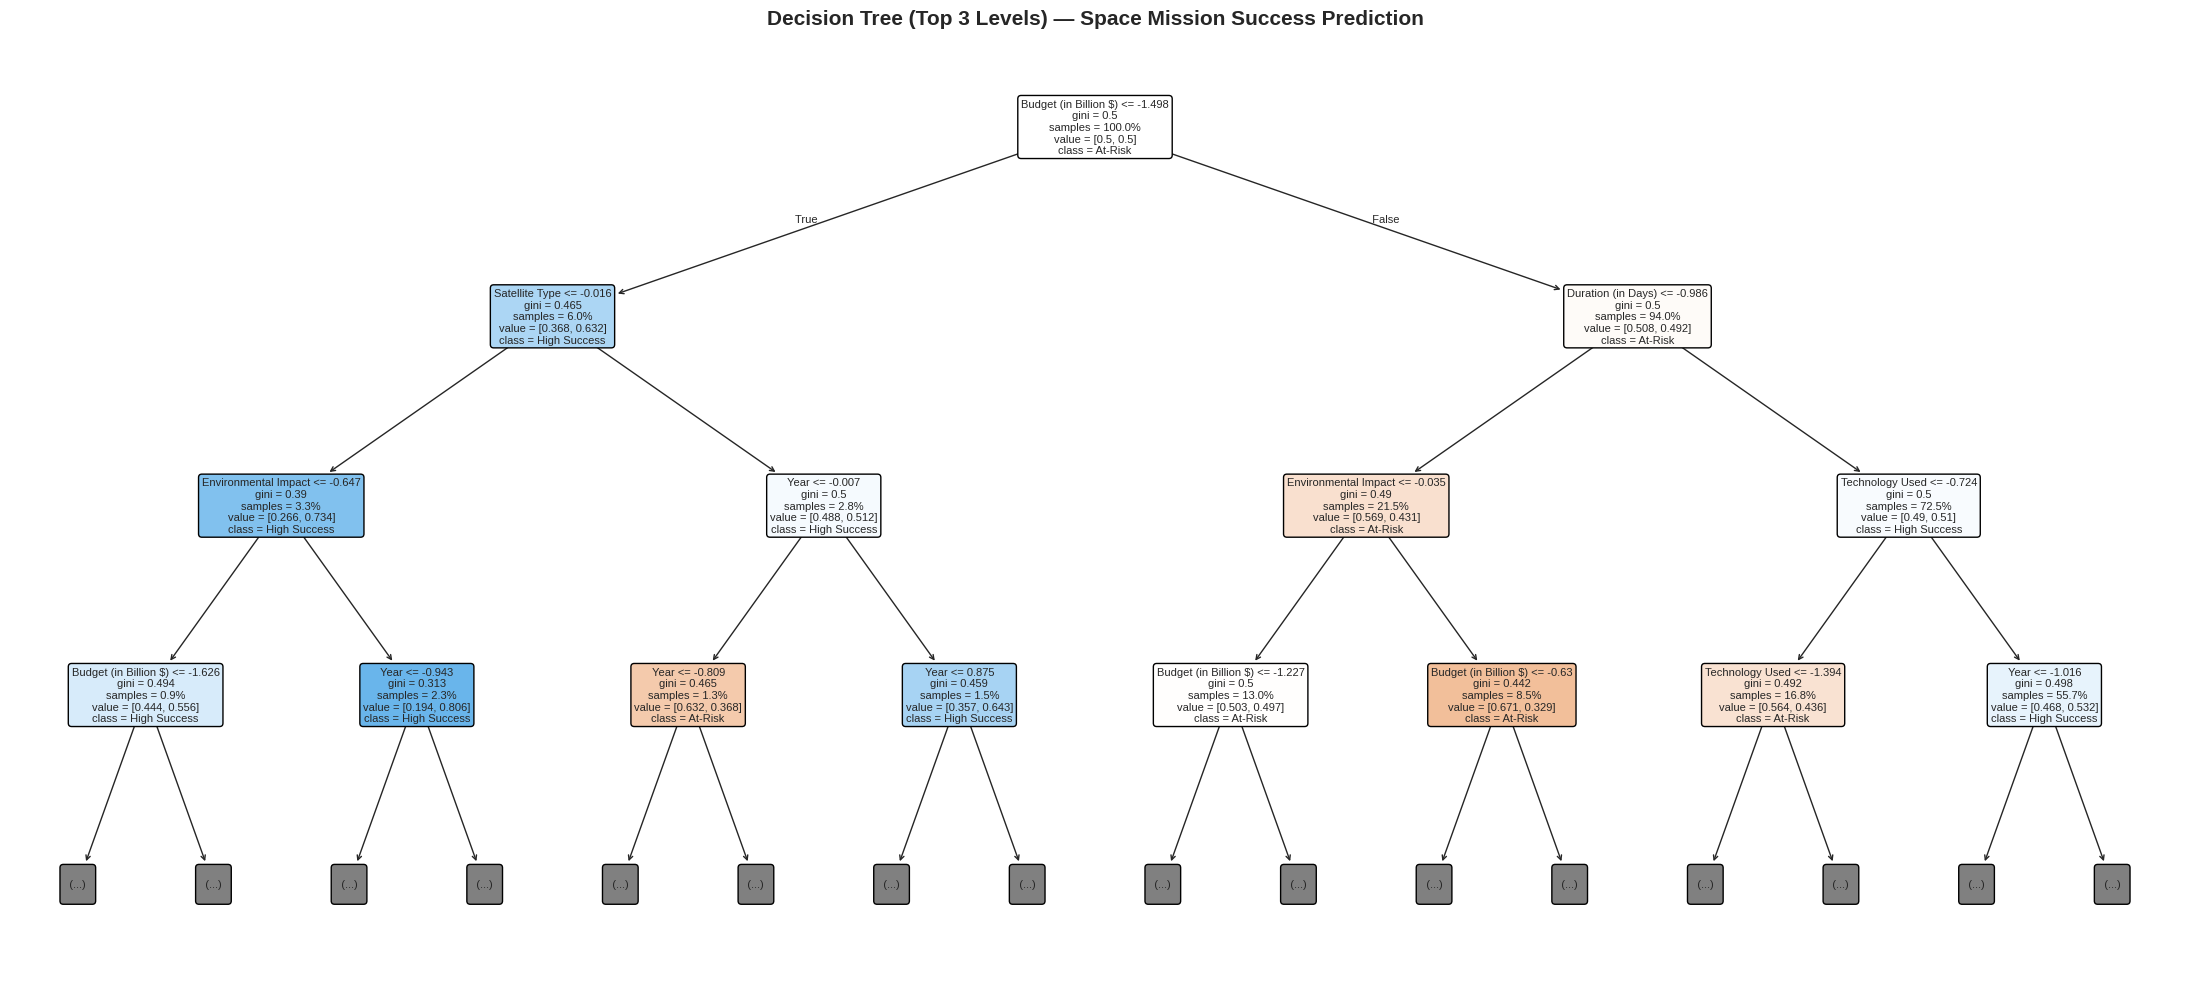

In [ ]:
# --- Visual tree (top 3 levels) ---
fig_tree, ax_tree = plt.subplots(figsize=(22, 10))
plot_tree(dt_model, max_depth=3,
          feature_names=list(X_train.columns),
          class_names=['At-Risk', 'High Success'],
          filled=True, rounded=True, fontsize=8,
          ax=ax_tree, proportion=True)
ax_tree.set_title('Decision Tree (Top 3 Levels) — Space Mission Success Prediction',
                  fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('datasets/classification_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()


Top 10 Feature Importances (Gini-based):
Budget (in Billion $)    0.2165
Year                     0.2066
Technology Used          0.1700
Duration (in Days)       0.1381
Satellite Type           0.0940
Environmental Impact     0.0852
Country                  0.0722
Mission Type             0.0174
Num_Collaborators        0.0000


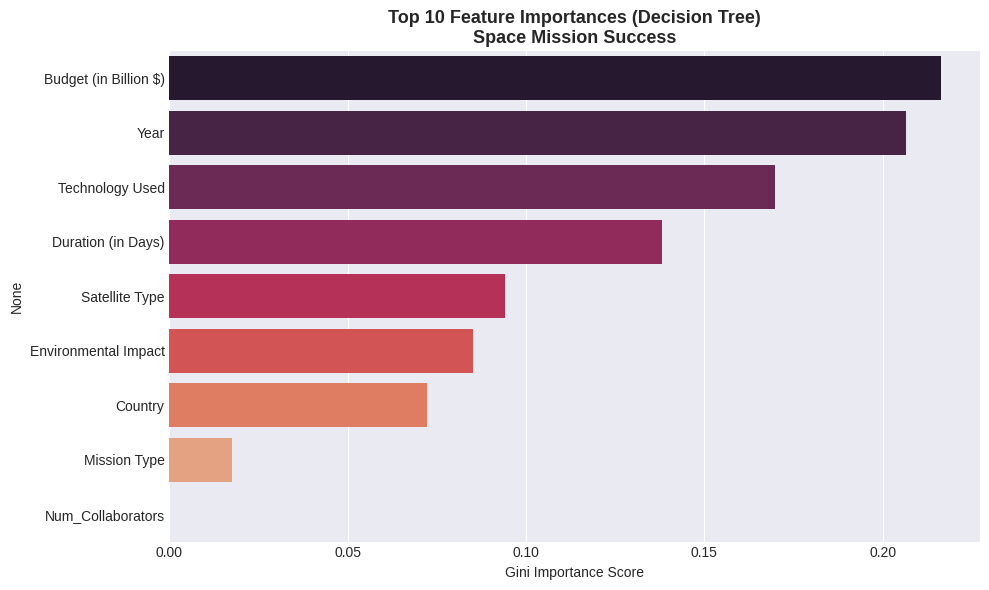

In [ ]:
# --- Feature importances ---
importances = dt_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

print("Top 10 Feature Importances (Gini-based):")
print(feat_imp.head(10).round(4).to_string())

fig_fi, ax_fi = plt.subplots(figsize=(10, 6))
top10 = feat_imp.head(10)
sns.barplot(x=top10.values, y=top10.index, ax=ax_fi, palette='rocket')
ax_fi.set_title('Top 10 Feature Importances (Decision Tree)\nSpace Mission Success',
                fontsize=13, fontweight='bold')
ax_fi.set_xlabel('Gini Importance Score')
plt.tight_layout()
plt.savefig('datasets/classification_feature_importance.png', dpi=150)
plt.show()


## 8  k-NN Sensitivity Analysis (Effect of k)

    Precision  Recall  F1-Score  ROC-AUC
k                                       
3      0.6152  0.5861    0.6003   0.5180
5      0.5942  0.5694    0.5816   0.5170
7      0.6088  0.5750    0.5914   0.5056
9      0.6024  0.5556    0.5780   0.5039
11     0.6146  0.5361    0.5727   0.4973


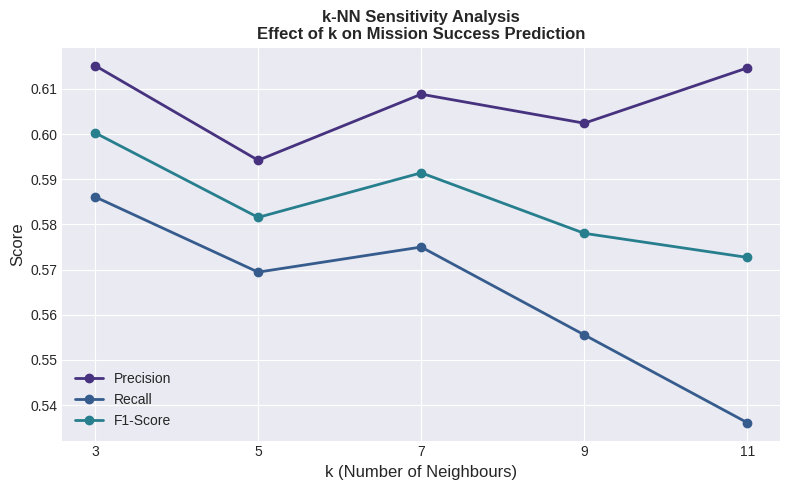

In [ ]:
k_values  = [3, 5, 7, 9, 11]
k_results = []

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='euclidean',
                                    weights='distance', n_jobs=-1)
    knn_tmp.fit(X_tr, y_tr)
    yp = knn_tmp.predict(X_test)
    ypr = knn_tmp.predict_proba(X_test)[:, 1]
    k_results.append({
        'k':          k,
        'Precision':  precision_score(y_test, yp),
        'Recall':     recall_score(y_test, yp),
        'F1-Score':   f1_score(y_test, yp),
        'ROC-AUC':    roc_auc_score(y_test, ypr),
    })

k_df = pd.DataFrame(k_results).set_index('k')
print(k_df.round(4).to_string())

fig_k, ax_k = plt.subplots(figsize=(8, 5))
k_df[['Precision', 'Recall', 'F1-Score']].plot(ax=ax_k, marker='o', linewidth=2)
ax_k.set_xlabel('k (Number of Neighbours)', fontsize=12)
ax_k.set_ylabel('Score', fontsize=12)
ax_k.set_title('k-NN Sensitivity Analysis\nEffect of k on Mission Success Prediction',
               fontsize=12, fontweight='bold')
ax_k.set_xticks(k_values)
ax_k.legend(fontsize=10)
plt.tight_layout()
plt.savefig('datasets/classification_knn_sensitivity.png', dpi=150)
plt.show()


## 9  5-Fold Stratified Cross-Validation

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                              cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = {'CV F1 Mean': scores.mean().round(4),
                        'CV F1 Std':  scores.std().round(4)}
    print(f"  {name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).T
cv_df


  Decision Tree: F1 = 0.6699 ± 0.0250
  Naive Bayes (Gaussian): F1 = 0.7504 ± 0.0008
  k-NN (k=7): F1 = 0.6648 ± 0.0210


,CV F1 Mean,CV F1 Std
Decision Tree,0.6699,0.0250
Naive Bayes (Gaussian),0.7504,0.0008
k-NN (k=7),0.6648,0.0210


## 10  Comparative Results Summary

In [ ]:
results_df = pd.DataFrame(results).T
display(results_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC','PR-AUC']].round(4))


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Decision Tree,0.4617,0.5678,0.4306,0.4897,0.4788,0.6150
Naive Bayes (Gaussian),0.4917,0.5868,0.5167,0.5495,0.4731,0.5821
k-NN (k=7),0.5233,0.6088,0.5750,0.5914,0.5056,0.6144


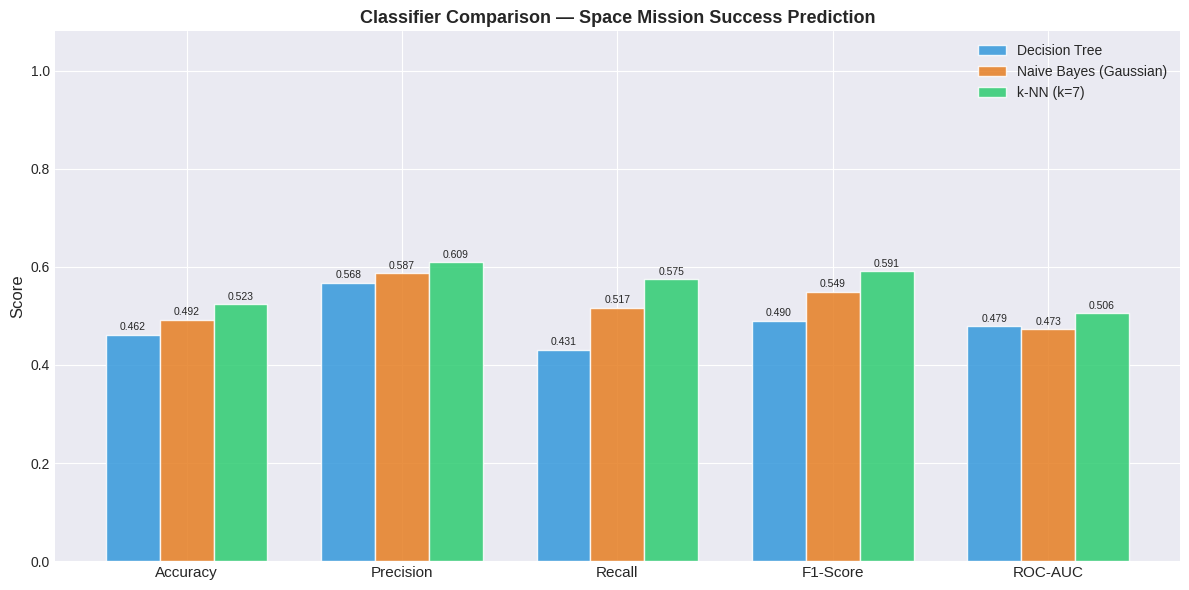

In [ ]:
# --- Radar / bar comparison chart ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i],
                  alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classifier Comparison — Space Mission Success Prediction',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('datasets/classification_comparison_bar.png', dpi=150)
plt.show()


In [ ]:
# --- Times comparison ---
display(results_df[['Train Time (s)', 'Predict Time (s)']])


,Train Time (s),Predict Time (s)
Decision Tree,0.0186,0.0029
Naive Bayes (Gaussian),0.0032,0.0029
k-NN (k=7),0.0061,0.0872


In [ ]:
best_f1  = results_df['F1-Score'].idxmax()
best_rec = results_df['Recall'].idxmax()
best_roc = results_df['ROC-AUC'].idxmax()

print(f"""
INTERPRETATION
{'='*60}
  Best F1-Score  :  {best_f1} ({results_df.loc[best_f1,  'F1-Score']:.4f})
  Best Recall    :  {best_rec} ({results_df.loc[best_rec, 'Recall']:.4f})
  Best ROC-AUC   :  {best_roc} ({results_df.loc[best_roc, 'ROC-AUC']:.4f})

KEY OBSERVATIONS
{'='*60}
  • Accuracy alone is misleading: a "always High-Success" model
    gets ~60% accuracy but catches ZERO at-risk missions.
  • F1-Score is the primary comparison metric here.
  • Decision Tree — fast, interpretable; ideal for XAI requirements.
  • Naive Bayes — extremely fast training; works when features are
    approximately conditionally independent given the class.
  • k-NN — captures complex non-linear patterns but prediction is
    slower at scale (the entire training set is the model).
""")

results_df.to_csv('datasets/classification_metrics.csv')
print("Saved: datasets/classification_metrics.csv ✓")
print("\nMODULE 4 COMPLETE ✓")



INTERPRETATION
  Best F1-Score  :  k-NN (k=7) (0.5914)
  Best Recall    :  k-NN (k=7) (0.5750)
  Best ROC-AUC   :  k-NN (k=7) (0.5056)

KEY OBSERVATIONS
  • Accuracy alone is misleading: a "always High-Success" model
    gets ~60% accuracy but catches ZERO at-risk missions.
  • F1-Score is the primary comparison metric here.
  • Decision Tree — fast, interpretable; ideal for XAI requirements.
  • Naive Bayes — extremely fast training; works when features are
    approximately conditionally independent given the class.
  • k-NN — captures complex non-linear patterns but prediction is
    slower at scale (the entire training set is the model).

Saved: datasets/classification_metrics.csv ✓

MODULE 4 COMPLETE ✓
